In [ ]:
!pip install gradio scikit-learn pandas numpy

In [ ]:
# ==============================
# INSTALL LIBRARIES
# ==============================
!pip install gradio scikit-learn pandas numpy matplotlib

# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# ==============================
# UPLOAD DATASET
# ==============================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("spotify_tracks.csv")  # Change if needed

# ==============================
# CLEAN DATA
# ==============================
df = df.dropna()

# Create Target Column
df['Hit'] = df['popularity'].apply(lambda x: 1 if x > 70 else 0)

print("Hit vs Not Hit count:")
print(df['Hit'].value_counts())

# ==============================
# SELECT FEATURES
# ==============================
features = [
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'acousticness',
    'valence',
    'speechiness'
]

X = df[features]
y = df['Hit']

# ==============================
# SPLIT DATA
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# TRAIN RANDOM FOREST
# ==============================
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# EVALUATION
# ==============================
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("\nModel Accuracy:", round(accuracy*100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# ==============================
# FEATURE IMPORTANCE
# ==============================
importance = model.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

# ==============================
# PREDICTION FUNCTION FOR UI
# ==============================
def predict_hit(danceability, energy, loudness, tempo,
                acousticness, valence, speechiness):

    input_data = np.array([[danceability, energy, loudness,
                            tempo, acousticness,
                            valence, speechiness]])

    prediction = model.predict(input_data)[0]
    probability = max(model.predict_proba(input_data)[0])

    if prediction == 1:
        result = "🔥 Hit Song"
    else:
        result = "🎵 Not a Hit"

    return f"{result}\nConfidence: {round(probability*100,2)}%"

# ==============================
# CREATE UI
# ==============================
interface = gr.Interface(
    fn=predict_hit,
    inputs=[
        gr.Slider(0,1,label="Danceability"),
        gr.Slider(0,1,label="Energy"),
        gr.Slider(-60,0,label="Loudness"),
        gr.Slider(0,250,label="Tempo"),
        gr.Slider(0,1,label="Acousticness"),
        gr.Slider(0,1,label="Valence"),
        gr.Slider(0,1,label="Speechiness")
    ],
    outputs="text",
    title="🔥 Hit Song Predictor (Random Forest)",
    description="Adjust features to predict if song will be a Hit"
)

interface.launch()

KeyboardInterrupt: 

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spotify.csv to spotify.csv


In [ ]:
df = pd.read_csv('/content/spotify.csv')

Hit vs Not Hit Count:
Hit
0    61761
1      556
Name: count, dtype: int64

Model Accuracy: 98.89 %


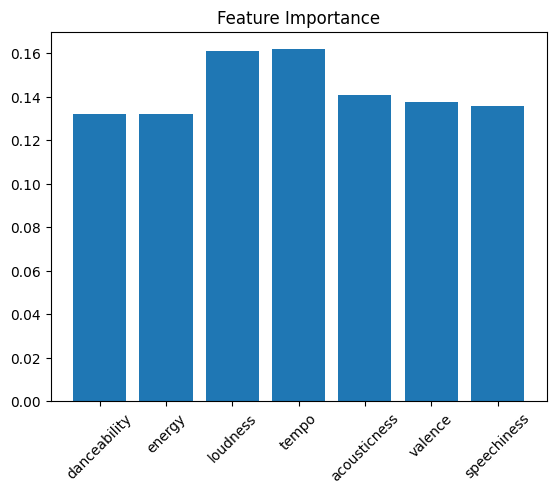

In [ ]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ==============================
# LOAD DATASET FROM DRIVE
# ==============================
df = pd.read_csv('/content/spotify.csv')

# ==============================
# CLEAN DATA
# ==============================
df = df.dropna()

# Create Target Column (Hit = 1 if popularity > 70)
df['Hit'] = df['popularity'].apply(lambda x: 1 if x > 70 else 0)

print("Hit vs Not Hit Count:")
print(df['Hit'].value_counts())

# ==============================
# SELECT FEATURES
# ==============================
features = [
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'acousticness',
    'valence',
    'speechiness'
]

X = df[features]
y = df['Hit']

# ==============================
# SPLIT DATA
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# TRAIN RANDOM FOREST
# ==============================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# ==============================
# EVALUATE MODEL
# ==============================
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# ==============================
# FEATURE IMPORTANCE
# ==============================
importance = model.feature_importances_

plt.figure()
plt.bar(features, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [ ]:
# ==============================
# INSTALL GRADIO
# ==============================
!pip install gradio

import gradio as gr

# ==============================
# PREDICTION FUNCTION FOR UI
# ==============================
def predict_hit(danceability, energy, loudness, tempo,
                acousticness, valence, speechiness):

    input_data = np.array([[danceability, energy, loudness,
                            tempo, acousticness,
                            valence, speechiness]])

    prediction = model.predict(input_data)[0]
    probability = max(model.predict_proba(input_data)[0])

    if prediction == 1:
        result = "🔥 Hit Song"
    else:
        result = "🎵 Not a Hit"

    return f"{result}\nConfidence: {round(probability*100,2)}%"

# ==============================
# CREATE UI
# ==============================
interface = gr.Interface(
    fn=predict_hit,
    inputs=[
        gr.Slider(0,1,label="Danceability"),
        gr.Slider(0,1,label="Energy"),
        gr.Slider(-60,0,label="Loudness"),
        gr.Slider(0,250,label="Tempo"),
        gr.Slider(0,1,label="Acousticness"),
        gr.Slider(0,1,label="Valence"),
        gr.Slider(0,1,label="Speechiness")
    ],
    outputs="text",
    title="🔥 Hit Song Predictor",
    description="Adjust song features to predict whether it will be a Hit"
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5d6b41bf7468a4b7a1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# =====================================
# INSTALL LIBRARIES
# =====================================
!pip install gradio scikit-learn pandas numpy matplotlib

# =====================================
# IMPORT LIBRARIES
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# =====================================
# LOAD DATASET FROM GOOGLE DRIVE
# =====================================
# from google.colab import drive
# drive.mount('/content/drive')

df = pd.read_csv('/content/spotify.csv') # Changed from '/content/drive/MyDrive/spotify_tracks.csv'

# =====================================
# CLEAN DATA
# =====================================
df = df.dropna()

# Create Target Column
df['Hit'] = df['popularity'].apply(lambda x: 1 if x > 70 else 0)

print("Before Balancing:")
print(df['Hit'].value_counts())

# =====================================
# BALANCE DATASET (IMPORTANT FIX)
# =====================================
min_class = df['Hit'].value_counts().min()

df_balanced = pd.concat([
    df[df['Hit'] == 0].sample(min_class, random_state=42),
    df[df['Hit'] == 1].sample(min_class, random_state=42)
])

df = df_balanced

print("\nAfter Balancing:")
print(df['Hit'].value_counts())

# =====================================
# SELECT FEATURES
# =====================================
features = [
    'danceability',
    'energy',
    'loudness',
    'tempo',
    'acousticness',
    'valence',
    'speechiness'
]

X = df[features]
y = df['Hit']

# =====================================
# SPLIT DATA
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# TRAIN RANDOM FOREST
# =====================================
model = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================
# EVALUATE MODEL
# =====================================
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

# =====================================
# CREATIVE PREDICTION FUNCTION
# =====================================
def predict_hit(danceability, energy, loudness, tempo,
                acousticness, valence, speechiness):

    input_data = np.array([[danceability, energy, loudness,
                            tempo, acousticness,
                            valence, speechiness]])

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]
    confidence = probabilities[prediction] * 100

    if prediction == 1:
        result = "🔥 HIT SONG"
        insight = "High energy & strong musical dynamics detected!"
    else:
        result = "🎵 NOT A HIT"
        insight = "May require more engaging audio features."

    return result, insight, round(confidence, 2)

# =====================================
# CREATIVE MODERN UI
# =====================================
theme = gr.themes.Soft(primary_hue="purple", secondary_hue="pink")

with gr.Blocks(theme=theme) as app:

    gr.Markdown("""
    # 🎧 AI Hit Song Predictor
    ### Powered by Random Forest 🌲
    Adjust features and predict your next viral track!
    """)

    with gr.Row():
        with gr.Column():
            danceability = gr.Slider(0,1,label="💃 Danceability")
            energy = gr.Slider(0,1,label="⚡ Energy")
            loudness = gr.Slider(-60,0,label="🔊 Loudness")
            tempo = gr.Slider(0,250,label="🥁 Tempo")
            acousticness = gr.Slider(0,1,label="🎸 Acousticness")
            valence = gr.Slider(0,1,label="😊 Valence")
            speechiness = gr.Slider(0,1,label="🎤 Speechiness")

            btn = gr.Button("🚀 Predict")

        with gr.Column():
            result = gr.Textbox(label="Prediction")
            insight = gr.Textbox(label="AI Insight")
            confidence = gr.Slider(0,100,label="Confidence %", interactive=False)

    btn.click(
        predict_hit,
        inputs=[danceability, energy, loudness, tempo,
                acousticness, valence, speechiness],
        outputs=[result, insight, confidence]
    )

    gr.Markdown("### 📊 Feature Importance")

    gr.BarPlot(
        value={
            "Danceability": model.feature_importances_[0],
            "Energy": model.feature_importances_[1],
            "Loudness": model.feature_importances_[2],
            "Tempo": model.feature_importances_[3],
            "Acousticness": model.feature_importances_[4],
            "Valence": model.feature_importances_[5],
            "Speechiness": model.feature_importances_[6],
        },
        x="index",
        y="value",
        title="Feature Impact on Hit Prediction"
    )

app.launch()

Before Balancing:
Hit
0    61761
1      556
Name: count, dtype: int64

After Balancing:
Hit
0    556
1    556
Name: count, dtype: int64

Model Accuracy: 65.92 %
Confusion Matrix:
[[64 56]
 [20 83]]


/tmp/ipykernel_462/4024204063.py:124: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme) as app:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8723269d93ad2270e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
app.launch(share=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8723269d93ad2270e6.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import numpy as np
import pandas as pd

# ==============================
# UPDATED PREDICTION FUNCTION
# ==============================
def predict_hit_chart(danceability, energy, loudness, tempo,
                      acousticness, valence, speechiness):

    input_data = np.array([[danceability, energy, loudness,
                            tempo, acousticness,
                            valence, speechiness]])

    prediction = model.predict(input_data)[0]
    probabilities = model.predict_proba(input_data)[0]

    hit_prob = probabilities[1] * 100
    not_hit_prob = probabilities[0] * 100

    if prediction == 1:
        result = "🔥 HIT SONG"
    else:
        result = "🎵 NOT A HIT"

    # Create dataframe for bar chart
    chart_data = pd.DataFrame({
        "Category": ["Not Hit", "Hit"],
        "Probability (%)": [not_hit_prob, hit_prob]
    })

    return result, round(max(hit_prob, not_hit_prob),2), chart_data


# ==============================
# CREATIVE UI WITH BARCHART
# ==============================
with gr.Blocks() as app:

    gr.Markdown("# 🎧 AI Hit Song Predictor")
    gr.Markdown("### Predict & Visualize Probability")

    with gr.Row():
        with gr.Column():
            danceability = gr.Slider(0,1,label="💃 Danceability")
            energy = gr.Slider(0,1,label="⚡ Energy")
            loudness = gr.Slider(-60,0,label="🔊 Loudness")
            tempo = gr.Slider(0,250,label="🥁 Tempo")
            acousticness = gr.Slider(0,1,label="🎸 Acousticness")
            valence = gr.Slider(0,1,label="😊 Valence")
            speechiness = gr.Slider(0,1,label="🎤 Speechiness")

            btn = gr.Button("🚀 Predict")

        with gr.Column():
            result = gr.Textbox(label="Prediction Result")
            confidence = gr.Number(label="Confidence %")
            chart = gr.BarPlot(x="Category", y="Probability (%)",
                               title="Prediction Probability")

    btn.click(
        predict_hit_chart,
        inputs=[danceability, energy, loudness, tempo,
                acousticness, valence, speechiness],
        outputs=[result, confidence, chart]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7f7be99ac8c708a3d3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
